# Multi-DOF, multi-objective beamline optimization (blop) with raytracing (Shadow)
khchan@lbl.gov awojdyla@lbl.gov, Sep 2025

This script is based on blop 0.71

using `python 3.10.9` environment


In [153]:
from blop.utils import prepare_re_env

%run -i $prepare_re_env.__file__ --db-type=temp
# it would be great to have a proper bluesky database

<Figure size 640x480 with 0 Axes>

In [154]:
%matplotlib inline

import Shadow
import numpy as np
import matplotlib as mpl
from pathlib import Path
from matplotlib import pyplot as plt

In [155]:
# getting the beam size in for any beam shape
def beam_rms_size(x, y, I):
    """
    Compute the RMS (root mean square) beam size and centroid from ray data.

    This function calculates the second-moment beam size in both X and Y
    directions directly from a list of ray positions, using only rays
    that exist (I > 0).

    Parameters
    ----------
    x : 1D numpy.ndarray
        Array of X positions of rays (in meters, mm, etc.).
    y : 1D numpy.ndarray
        Array of Y positions of rays (same units as x).
    I : 1D numpy.ndarray
        Array of ray existence flags or intensities.
        Rays with I <= 0 are ignored.

    Returns
    -------
    total_rays : int
        Number of rays considered (I > 0).
    sigma_x : float
        RMS beam size in X direction.
    sigma_y : float
        RMS beam size in Y direction.
    x_centroid : float
        Centroid position in X.
    y_centroid : float
        Centroid position in Y.

    Notes
    -----
    - The RMS size is defined as:
        sigma_x = sqrt(mean((x - x_centroid)^2))
        sigma_y = sqrt(mean((y - y_centroid)^2))
      over all valid rays.
    - For a Gaussian beam, the FWHM can be obtained as:
        FWHM = 2.35482 * sigma
    - This method is robust and fast, and does not assume a Gaussian profile.

    Examples
    --------
    >>> total, sigma_x, sigma_y, cx, cy = beam_rms_size_from_rays(x, y, I)
    >>> fwhm_x = 2.35482 * sigma_x
    >>> fwhm_y = 2.35482 * sigma_y
    """
    # Keep only rays with I > 0
    mask = I > 0
    #mask = np.all((np.abs(x) > 1e-8, np.abs(x) < 2e-3, np.abs(y) > 1e-8, np.abs(y) < 2e-3), 0)
    x_valid = x[mask]
    y_valid = y[mask]
    I = I[mask]

    # intensity
    intensity = np.sum(I)
    total_rays = len(x_valid)
    if total_rays == 0:
        return 1, 100, 100, 100, 100

    # Centroid positions
    x_centroid = np.mean(x_valid)
    y_centroid = np.mean(y_valid)

    # RMS sizes
    sigma_x = np.sqrt(np.mean((x_valid - x_centroid) ** 2))
    sigma_y = np.sqrt(np.mean((y_valid - y_centroid) ** 2))

    return intensity, sigma_x, sigma_y, x_centroid, y_centroid

Define the beamline5.3.1 by shadow

In [156]:
"""
# mirror pitch (DOF1)
oe1.X_ROT = 1e-09
# mirror bend (DOF2)
oe1.R_MAJ = 2400.0

# Mono angle – same variable  (DOF3)
oe2.T_INCIDENCE = 75.6898061088
oe2.T_REFLECTION = 75.6898061088
oe3.T_INCIDENCE = 75.6898061088
oe3.T_REFLECTION = 75.6898061088

# slit position (DOF4)
oe4.CX_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe4.CZ_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# write (1) or not (0) SHADOW files start.xx end.xx star.xx

iwrite = 0
"""

def beamline_531(X_ROT = 0, R_MAJ = 2400, SLIT_CX = 0, SLIT_CZ = 0, SLIT_RX = 1e-3, SLIT_RZ = 1e-3):
    # Define the object in beamline
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()
    oe3 = Shadow.OE()
    oe4 = Shadow.OE()
    oe5 = Shadow.OE()
    
    
    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.F_POLAR = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0
    oe0.NPOINT = 40000
    oe0.PH1 = 8000.0
    oe0.SIGDIZ = 1e-05
    oe0.SIGMAX = 0.0003
    oe0.SIGMAZ = 0.0001
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    
    
    
    oe1.ALPHA = 180.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = R_MAJ
    oe1.R_MIN = 0.06
    oe1.T_IMAGE = 0.0
    oe1.T_INCIDENCE = 89.7135211024
    oe1.T_REFLECTION = 89.7135211024
    oe1.T_SOURCE = 12.0
    oe1.X_ROT = X_ROT
    oe1.Y_ROT = 0
    
    
    oe2.DUMMY = 100.0
    oe2.FILE_REFL = b'./bragg.dat'
    oe2.FWRITE = 1
    oe2.F_CENTRAL = 1
    oe2.F_CRYSTAL = 1
    oe2.PHOT_CENT = 8000.0
    oe2.R_LAMBDA = 5000.0
    oe2.T_IMAGE = 0.0
    oe2.T_INCIDENCE = 75.6898061088
    oe2.T_REFLECTION = 75.6898061088
    
    
    
    oe3.ALPHA = 180.0
    oe3.DUMMY = 100.0
    oe3.FILE_REFL = b'./bragg.dat'
    oe3.FWRITE = 1
    oe3.F_CENTRAL = 1
    oe3.F_CRYSTAL = 1
    oe3.PHOT_CENT = 8000.0
    oe3.R_LAMBDA = 5000.0
    oe3.T_IMAGE = 0.0
    oe3.T_INCIDENCE = 75.6898061088
    oe3.T_REFLECTION = 75.6898061088
    oe3.T_SOURCE = 0.2
    
    
    
    oe4.CX_SLIT = np.array([SLIT_CX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.CZ_SLIT = np.array([SLIT_CZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.DUMMY = 100.0
    oe4.FWRITE = 3
    oe4.F_REFRAC = 2
    oe4.F_SCREEN = 1
    oe4.I_SLIT = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    oe4.N_SCREEN = 1
    oe4.RX_SLIT = np.array([SLIT_RX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.RZ_SLIT = np.array([SLIT_RZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.T_IMAGE = 0.0
    oe4.T_INCIDENCE = 0.0
    oe4.T_REFLECTION = 180.0
    oe4.T_SOURCE = 0.8
    
    
    
    oe5.DUMMY = 100.0
    oe5.FWRITE = 3
    oe5.F_REFRAC = 2
    oe5.F_SCREEN = 1
    oe5.N_SCREEN = 1
    oe5.T_IMAGE = 0.0
    oe5.T_INCIDENCE = 0.0
    oe5.T_REFLECTION = 180.0
    oe5.T_SOURCE = 1.0
    
    
    
    
    beam.genSource(oe0)
    beam.traceOE(oe1,1)
    beam.traceOE(oe2,2)
    beam.traceOE(oe3,3)
    beam.traceOE(oe4,4)
    beam.traceOE(oe5,5)
    
    X = beam.getshcol(1)
    Y = beam.getshcol(3)
    # normalize the intensity by the number of rays
    I = beam.getshcol(10)/oe0.NPOINT
    return X,Y,I

0.3782000000000001


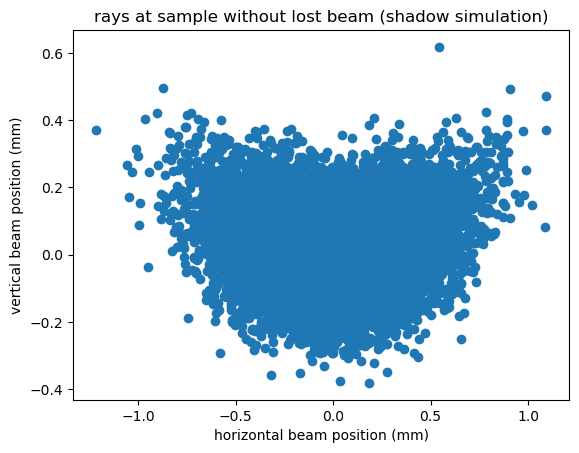

In [157]:
(X,Y,I) = beamline_531(0.0, 2450, 0, 0, 0.001, 0.001)
(X,Y,I) = beamline_531()
# removing the lost beam
X = X[I>0]
Y = Y[I>0]
I = I[I>0]
# intensity
print(np.sum(I))
plt.scatter(1e3*X,1e3*Y)
plt.title('rays at sample without lost beam (shadow simulation)')
plt.xlabel('horizontal beam position (mm)')
plt.ylabel('vertical beam position (mm)')
plt.show()

In [158]:
(total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, I)

In [159]:
total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

(0.3782000000000001,
 0.00029097532250257083,
 0.00010979606466933434,
 -9.91612298965964e-07,
 2.3570836069001804e-05)

In [160]:
from blop import Objective
# power density
objectives = [Objective(name="beamsize", description="beamsize", target="min"), 
             Objective(name="beam_intensity", description="beam_intensity", target="max"),
             Objective(name="slit_size", description="slit_size", target="min"),]

In [161]:
# from https://nsls-ii.github.io/blop/tutorials/introduction.html
# def digestion(df):
#     for index, entry in df.iterrows():
#         df.loc[index, "himmelblau"] = functions.himmelblau(entry.x1, entry.x2)

#     return df

#new: 
# unit log / normalize
def digestion(df):
    for index, entry in df.iterrows():
        X, Y, I = beamline_531(entry.x_rot, entry.r_maj, entry.slit_cx, entry.slit_cz, entry.slit_rx, entry.slit_rz)
        (total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, I) 
        df.loc[index, "beamsize"] = np.sqrt(sigma_x**2 + sigma_y**2)
        df.loc[index, "beam_intensity"] = np.sum(I)
        df.loc[index, "slit_size"] = np.sqrt(entry.slit_rx**2 + entry.slit_rz**2)
        print(sigma_x, sigma_y, total_intensity)

    return df

In [162]:
from blop import DOF

dofs = [
    DOF(name="x_rot", search_domain=(-0.05, 0.05)),
    DOF(name="r_maj", search_domain=(2000, 2800)),
    DOF(name="slit_cx", search_domain=(-0.05, 0.05)),
    DOF(name="slit_cz", search_domain=(-0.05, 0.05)),
    DOF(name="slit_rx", search_domain=(0.001, 0.005)),
    DOF(name="slit_rz", search_domain=(0.001, 0.005)),
]
# unit
dofs = [
    DOF(name="x_rot", search_domain=(-0.01, 0.02)),
    DOF(name="r_maj", search_domain=(2000, 2800)),
    DOF(name="slit_cx", search_domain=(-0.001, 0.003)),
    DOF(name="slit_cz", search_domain=(-0.001, 0.003)),
    DOF(name="slit_rx", search_domain=(0.0001, 0.01)),
    DOF(name="slit_rz", search_domain=(0.0001, 0.005)),
]

In [163]:
from blop import Agent

agent = Agent(
    dofs=dofs,
    objectives=objectives,
    digestion=digestion,
    db=db,
)

2025-09-17 11:32:26.645 INFO: Executing plan <generator object Agent.learn at 0x000002C5F98DF8B0>
2025-09-17 11:32:26.686 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x000002C5F41584C0> from 'idle' -> 'running'




Transient Scan ID: 1     Time: 2025-09-17 11:32:31
Persistent Unique Scan ID: 'db907640-fd72-4bbe-a3ab-ccdc0bdb453b'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj |    slit_cx |    slit_cz |    slit_rx |    slit_rz |
+-----------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 11:32:31.8 |      0.006 |   2376.715 |     -0.000 |      0.002 |      0.002 |      0.002 |
|         2 | 11:32:31.9 |      0.011 |   2530.479 |      0.000 |      0.001 |      0.001 |      0.001 |
|         3 | 11:32:31.9 |      0.017 |   2667.143 |     -0.000 |      0.000 |      0.001 |      0.000 |
|         4 | 11:32:32.0 |      0.018 |   2705.977 |      0.001 |      0.001 |      0.004 |      0.001 |
|         5 | 11:32:32.0 |      0.015 |   2686.721 |      0.002 |      0.002 |      0.003 |      0.001 |
|         6 | 11:32

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

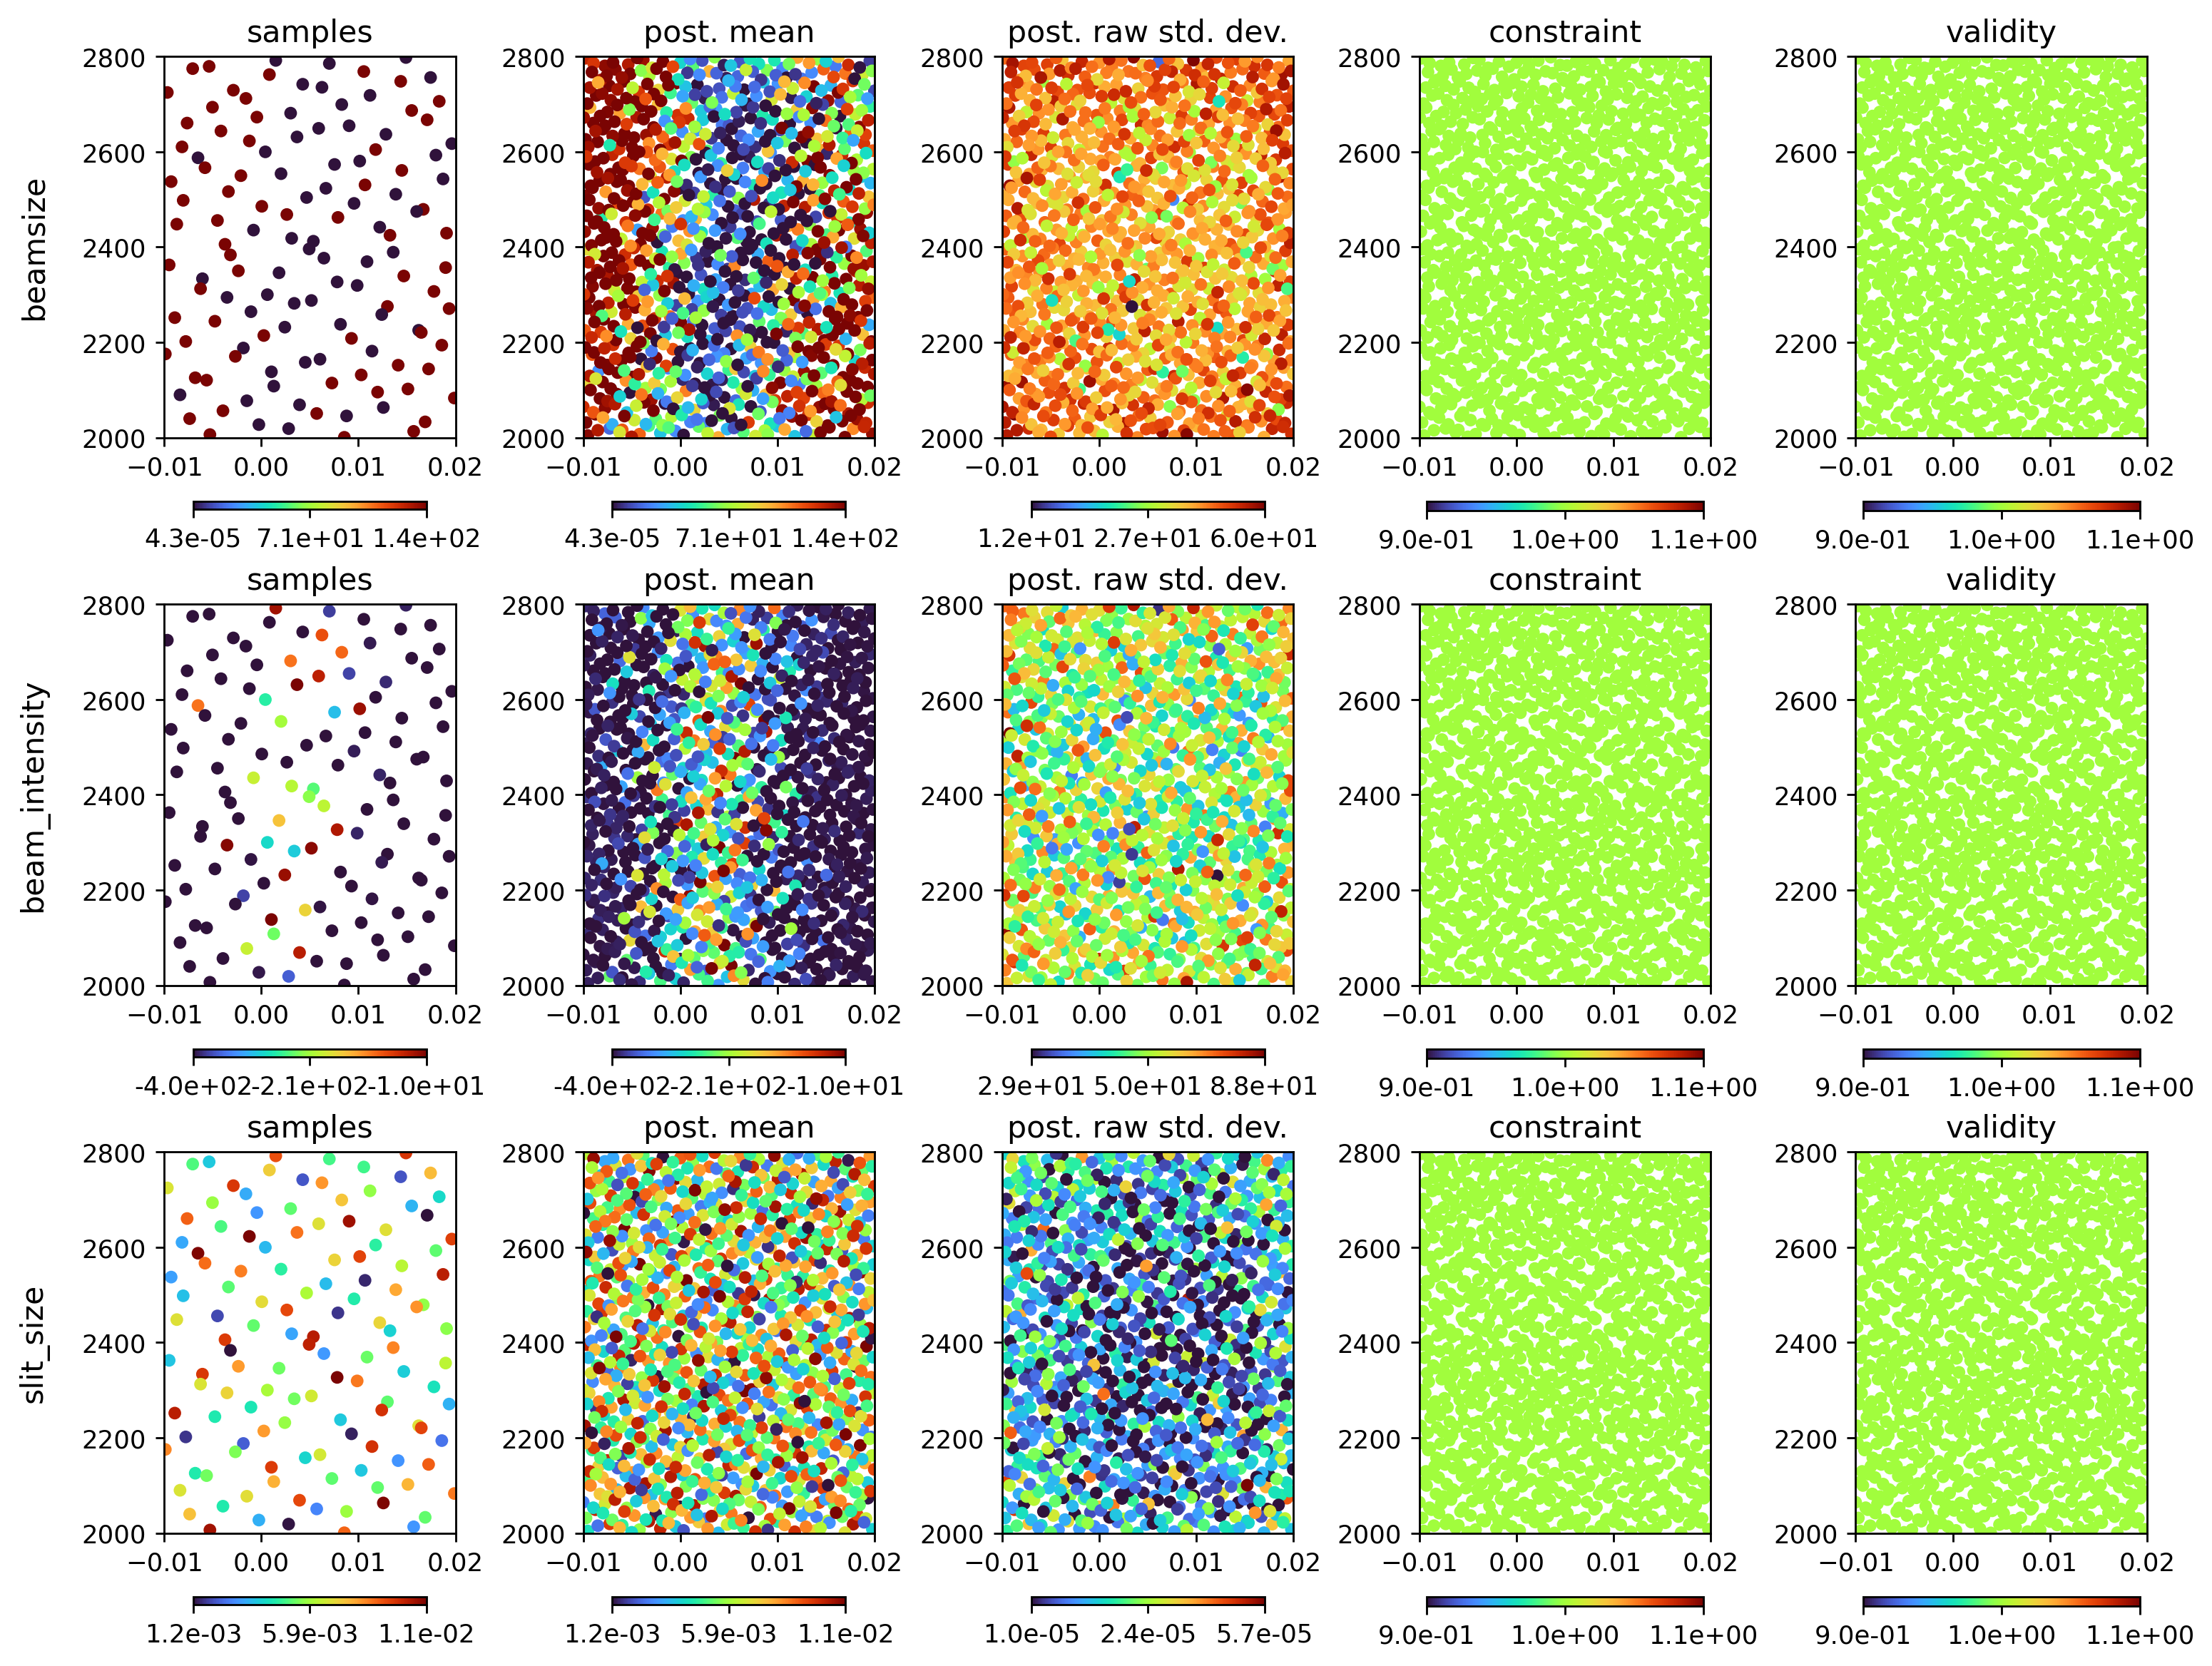

In [164]:
RE(agent.learn("quasi-random", n=128))
agent.plot_objectives()

In [165]:
agent.all_acqfs

,identifier,type,multitask_only,description
name,,,,
expected_improvement,ei,analytic,False,"The expected value of max(f(x) - \nu, 0), wher..."
expected_mean,em,analytic,False,The expected value at each input.
noisy_expected_hypervolume_improvement,nehvi,analytic,True,It's like a big box. How big is the box?
probability_of_improvement,pi,analytic,False,The probability that this input improves on th...
upper_confidence_bound,ucb,analytic,False,"The expected value, plus some multiple of the ..."
lower_bound_max_value_entropy,lbmve,monte_carlo,False,"Max entropy search, basically"
monte_carlo_expected_improvement,qei,monte_carlo,False,"The expected value of max(f(x) - \nu, 0), wher..."
monte_carlo_expected_mean,qem,monte_carlo,False,The expected value at each input.
monte_carlo_noisy_expected_hypervolume_improvement,qnehvi,monte_carlo,True,It's like a big box. How big is the box?


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


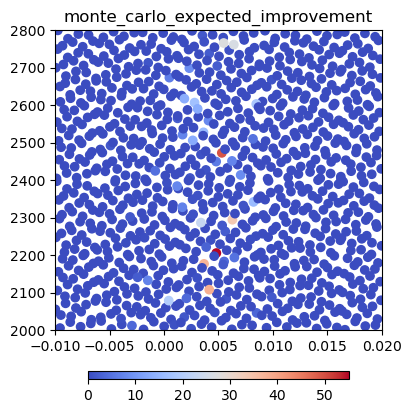

In [166]:
agent.plot_acquisition(acqf="qei")

In [92]:
agent.ask("qei", n=10)

{'points': {'x_rot': [-0.00096504856,
   -0.0005538473,
   -7.5279735e-05,
   -0.0005268967,
   -0.0006774217,
   -0.00057880953,
   -3.2819808e-06,
   -0.00067795534,
   -0.0010001035,
   -0.000288588],
  'r_maj': [2307.2559,
   2404.6885,
   2312.3604,
   2215.1218,
   2395.2832,
   2129.3855,
   2171.429,
   2246.6658,
   2057.3625,
   2152.1462],
  'slit_cx': [-0.00026411976,
   -0.0007797006,
   -0.00060774887,
   -0.00045842485,
   0.00019094348,
   0.00032567186,
   -0.0003211975,
   -0.001,
   -0.0005198297,
   -0.00086919765],
  'slit_cz': [-0.001,
   -0.00096232037,
   -0.0009717038,
   -0.0009129408,
   -0.001,
   -0.001,
   -0.00077917357,
   -0.001,
   -0.001,
   -0.00060294813],
  'slit_rx': [0.004176125,
   0.0038845483,
   0.0036994466,
   0.0037402064,
   0.0036250683,
   0.0039209328,
   0.003470059,
   0.0030771368,
   0.003519734,
   0.0037712865],
  'slit_rz': [0.0016370998,
   0.0017340347,
   0.001848568,
   0.0016912725,
   0.0016474596,
   0.0017403287,
   0.00

In [95]:
RE(agent.learn("qei", n=1, iterations=32))

2025-09-16 09:55:52.784 INFO: Executing plan <generator object Agent.learn at 0x000002C5F2676EA0>
2025-09-16 09:55:52.788 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x000002C5EA920700> from 'idle' -> 'running'




Transient Scan ID: 101     Time: 2025-09-16 09:55:54
Persistent Unique Scan ID: 'f9e508ec-6dbf-4f61-9a5c-4f99dd090a2a'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj |    slit_cx |    slit_cz |    slit_rx |    slit_rz |
+-----------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 09:55:54.3 |      0.000 |   2039.566 |      0.001 |      0.000 |      0.003 |      0.003 |
+-----------+------------+------------+------------+------------+------------+------------+------------+
generator list_scan ['f9e508ec'] (scan num: 101)



0.0002983296561803261 0.00029616143480005395 22453


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 102     Time: 2025-09-16 09:55:57
Persistent Unique Scan ID: '74d6b393-2330-4c99-9582-fd969db43c47'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj |    slit_cx |    slit_cz |    slit_rx |    slit_rz |
+-----------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 09:55:57.4 |      0.008 |   2341.293 |      0.000 |      0.001 |      0.008 |      0.001 |
+-----------+------------+------------+------------+------------+------------+------------+------------+
generator list_scan ['74d6b393'] (scan num: 102)



0.0014232547274592197 0.00022038216492000236 1096


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\botorch\optim\optimize.py:331: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(


...



Transient Scan ID: 131     Time: 2025-09-16 09:56:56
Persistent Unique Scan ID: 'd0e3a31a-7a17-4c17-a81f-f44922aec292'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj |    slit_cx |    slit_cz |    slit_rx |    slit_rz |
+-----------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 09:56:56.8 |     -0.010 |   2314.839 |      0.003 |      0.002 |      0.005 |      0.002 |
+-----------+------------+------------+------------+------------+------------+------------+------------+
generator list_scan ['d0e3a31a'] (scan num: 131)



100 100 1


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 132     Time: 2025-09-16 09:56:59
Persistent Unique Scan ID: 'c4691a2c-4a05-4314-ab67-54901ac19683'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj |    slit_cx |    slit_cz |    slit_rx |    slit_rz |
+-----------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 09:56:59.7 |      0.019 |   2286.481 |     -0.001 |      0.002 |      0.006 |      0.004 |
+-----------+------------+------------+------------+------------+------------+------------+------------+
generator list_scan ['c4691a2c'] (scan num: 132)



100 100 1


2025-09-16 09:57:00.745 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x000002C5EA920700> from 'running' -> 'idle'
2025-09-16 09:57:00.747 INFO: Cleaned up from plan <generator object Agent.learn at 0x000002C5F2676EA0>


('f9e508ec-6dbf-4f61-9a5c-4f99dd090a2a',
 '74d6b393-2330-4c99-9582-fd969db43c47',
 '0533e8db-854d-4f6a-b8b8-acf94a1e210f',
 'b34c4f10-16a7-4f23-be1d-b5107060ab18',
 'b6818da1-d319-4f7a-a3ad-019c5f99f5b6',
 '4fe8e144-251a-4bea-ae11-3cc84741a2ca',
 'f21665bf-c572-41c8-86aa-a00e028bc80f',
 '0aa9b0d0-700b-4594-85ee-e3cdadf39c91',
 '75df1d5a-7953-4641-949a-a7c2d474b471',
 'a4ea88db-6462-454a-aa2f-69b0241089da',
 '8c6b78d7-19b4-400e-8835-80a0ac753b78',
 'd6847366-0fac-4f7a-8def-7871b4a3df67',
 '42141369-9ccd-4d23-a111-474861f59a3b',
 '0a0bc6b5-05ba-46ad-9c2f-0e70c0381881',
 '5de3ebcb-2755-445e-b6e3-9f2d47096b80',
 '46930376-7204-43a2-95c9-e45192677b59',
 '0aaaa032-96ce-43ee-84bc-37e4c014de36',
 '7f352351-40ea-4943-a2f3-53d7871a559f',
 '73c9d3d2-5265-4564-a6d7-d52298f2342f',
 'd1ea9912-644f-4f7f-9eef-72da037525ce',
 'ef913a33-d8ba-4cbb-b6ae-bf58d799479e',
 '32c8ad42-1107-471f-9442-5a6fade929b4',
 'ba8cb148-686a-458e-b1c5-69a69059cd7d',
 '6ad565d5-0a97-4a9c-a99f-51b7eb17e39a',
 '4f7b5e21-bee8-

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pyt

x_rot                                  0.001039
r_maj                               2138.063931
slit_cx                                0.000223
slit_cz                                0.000434
slit_rx                                0.008789
slit_rz                                0.002798
beamsize                               0.000396
beam_intensity                           -3.422
slit_size                              0.009223
time              2025-09-17 18:32:36.051255465
acqf                               quasi-random
Name: 113, dtype: object


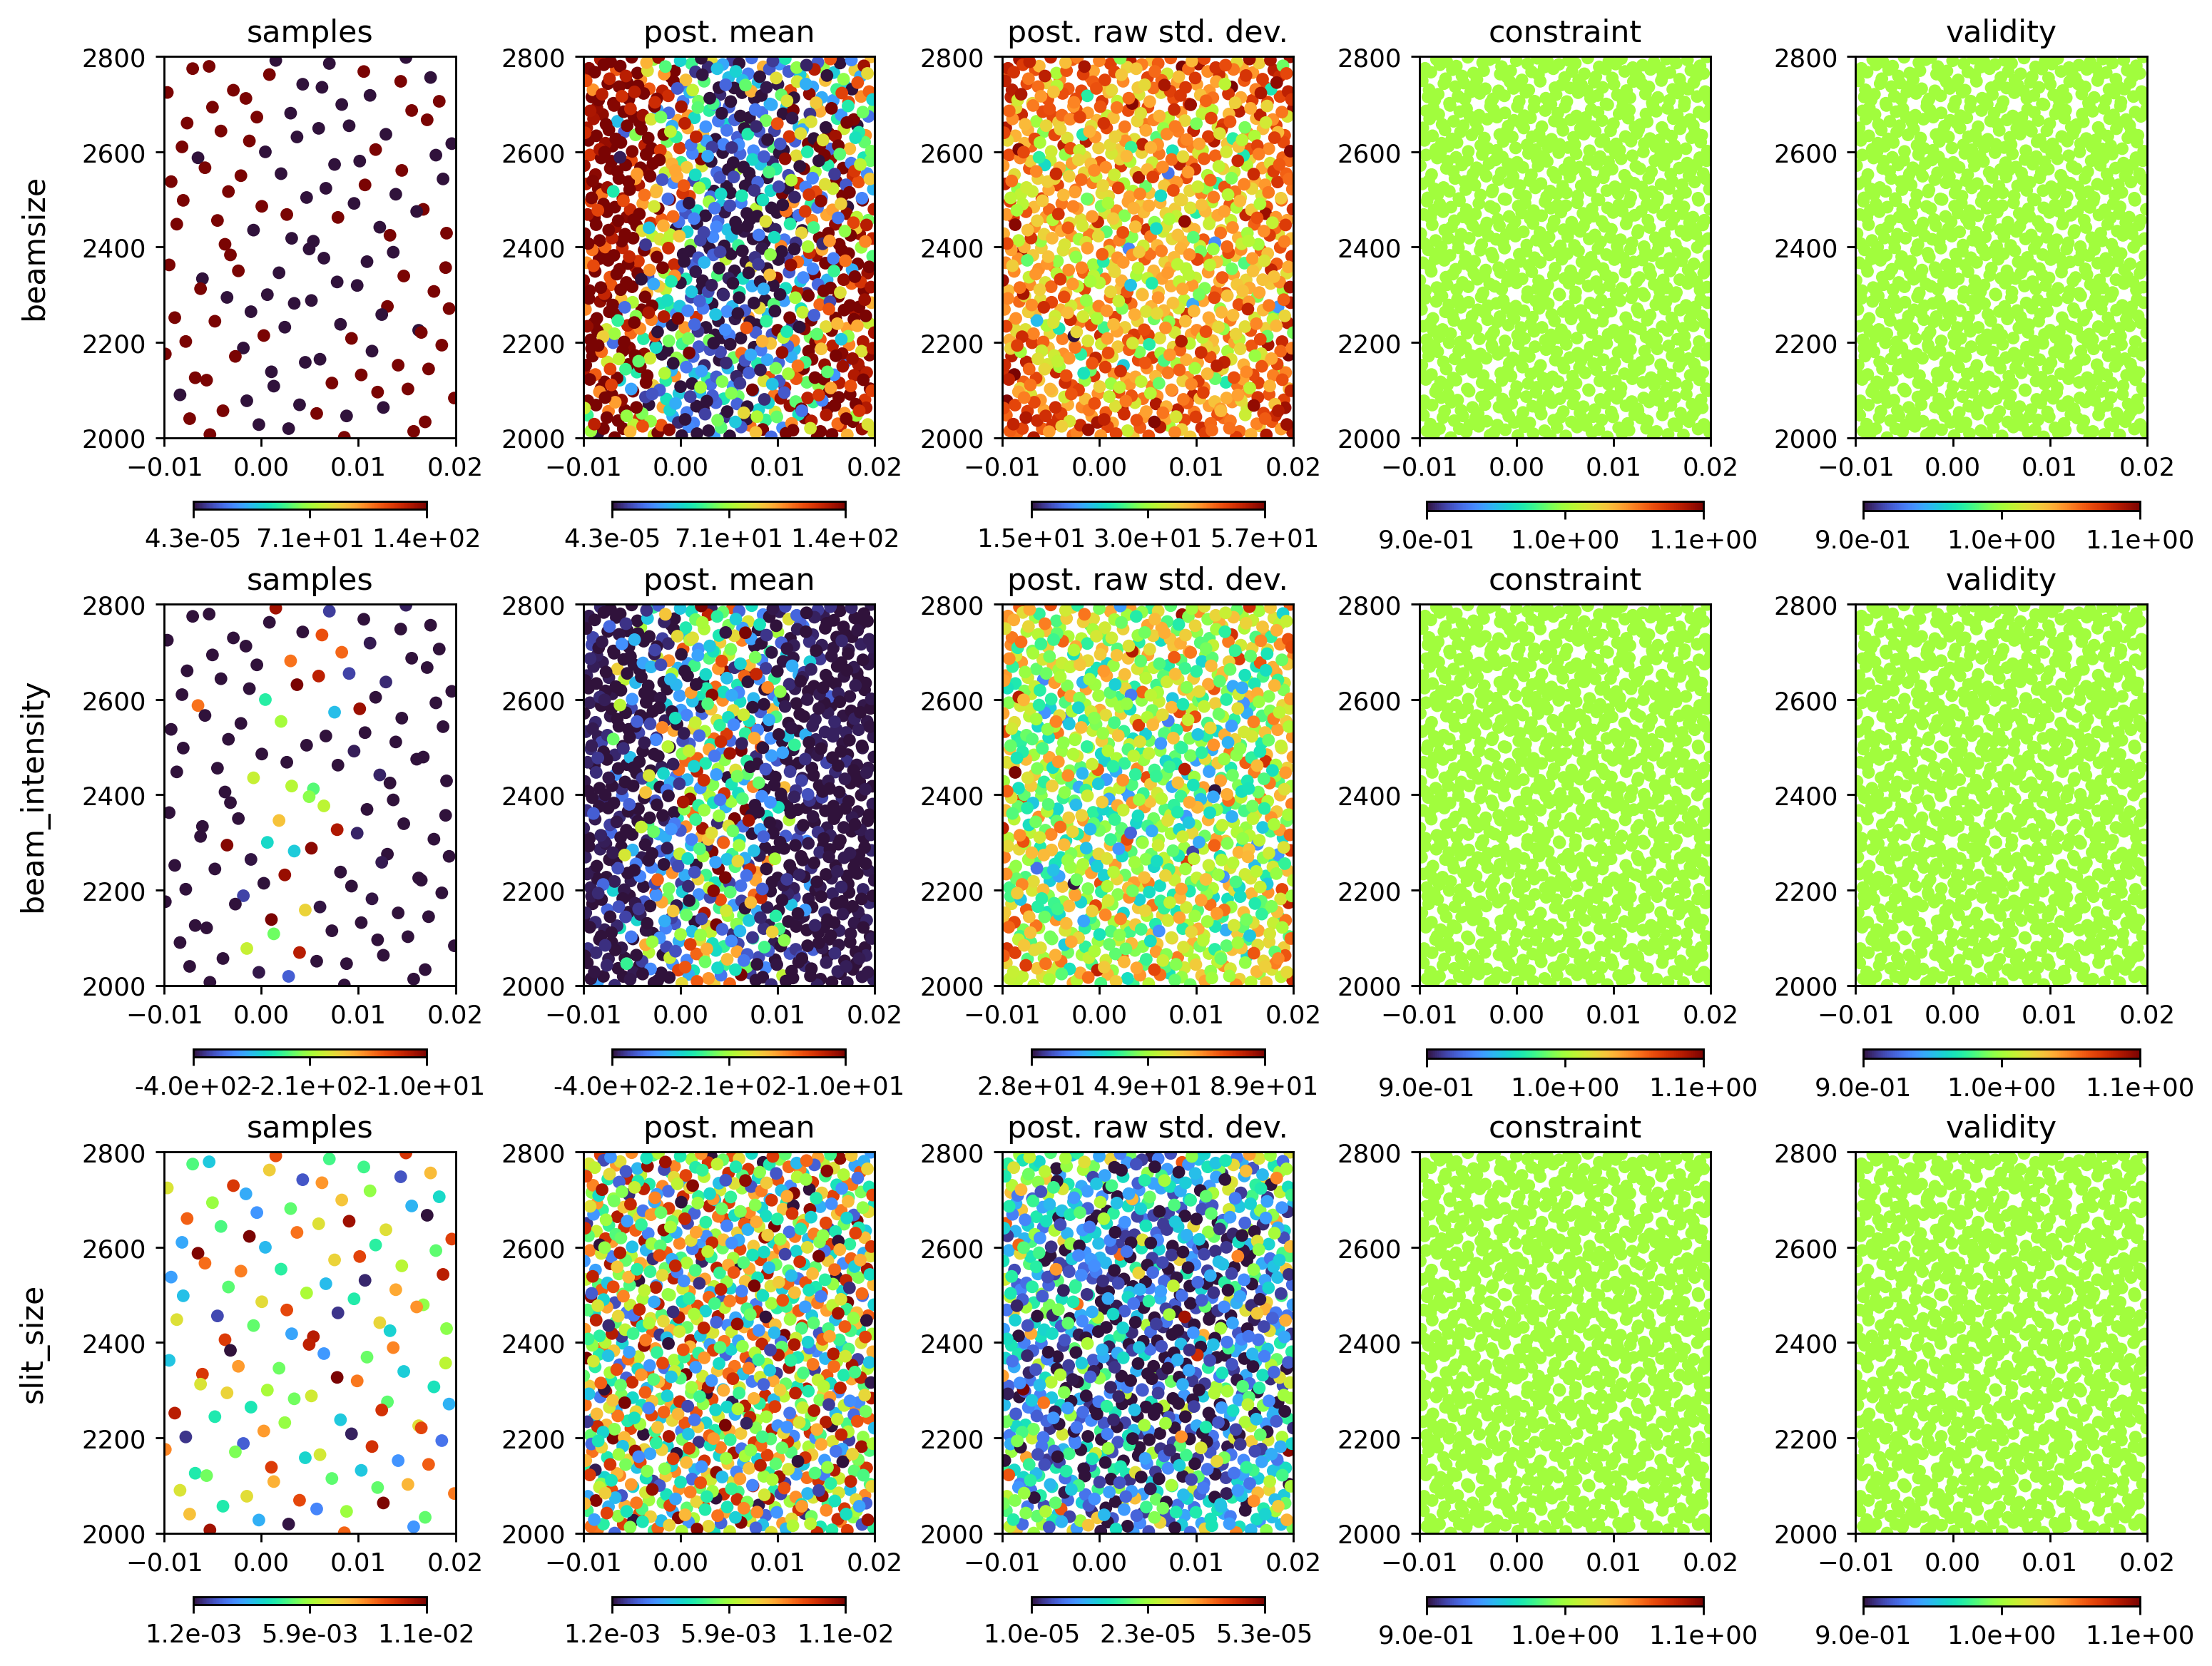

In [172]:
agent.plot_objectives()
print(agent.best)

(40000, 0.0003080367404167785, 0.0003456858962576669, 1.2537522217046096e-06, -0.00024833947221297546)
(40000, 0.00031459353946175294, 0.0002945482273534878, 7.217923657465585e-07, 0.00046216895223918594)
(39088, 0.00029052785556519395, 0.0001697263206366215, 3.6274110342346326e-06, -5.78988495851773e-05)
(39558, 0.0003129693321701904, 0.00036577396981269327, 1.146258451711265e-06, -0.00089914517572375)
(4431, 0.00021888880790416342, 0.00013984003346163046, 0.000545615648661667, 0.0020023210476233792)
(1651, 0.00018461276067761496, 8.79459721734355e-05, 0.00036834711326256235, 0.0017967656222920509)


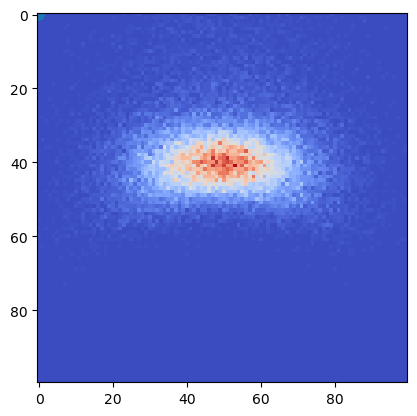

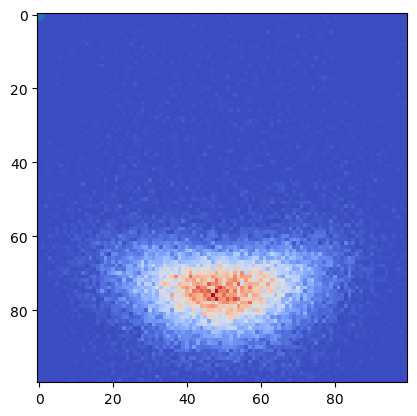

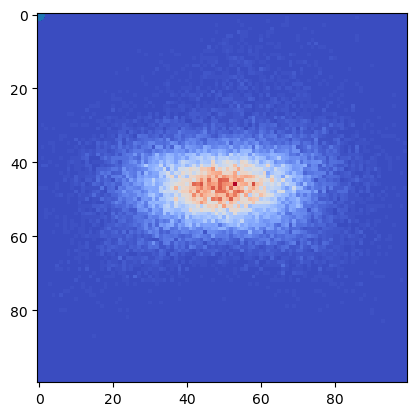

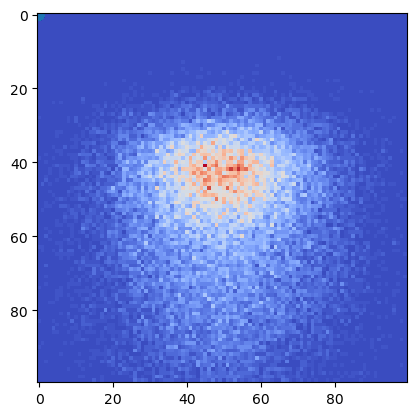

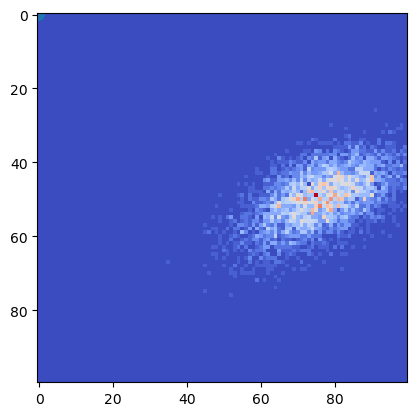

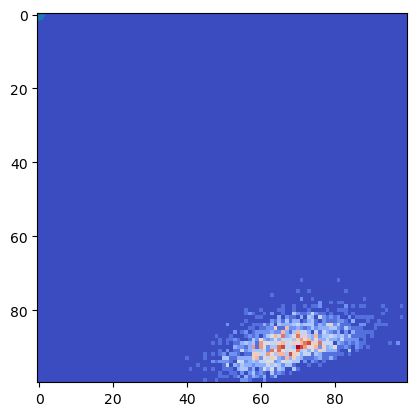

In [35]:
X, Y, I = beamline_531(-0.00044, 2338.219985, 0, 0, 1, 1)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist1, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-1, 1]])
plt.imshow(hist1.T)
X, Y, I = beamline_531(0.001068, 2243.403482, 0, 0, 1, 1)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist2, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-1, 1]])
plt.imshow(hist2.T)
X, Y, I = beamline_531(-0.000224, 2261.413574, 0.000568, -0.000626, 0.005, 0.002327)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-1, 1]])
plt.imshow(hist3.T)
X, Y, I = beamline_531(-0.002926, 2000, 0.000137, -0.000887, 0.004925, 0.001391)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-2, 0]])
plt.imshow(hist3.T)
X, Y, I = beamline_531(0.004817, 2306.087255, 0.002107, 0.002042, 0.001773, 0.001351)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [1, 3]])
plt.imshow(hist3.T)
X, Y, I = beamline_531( 0.004483, 2233.179498, 0.000949, 0.001478, 0.000528, 0.000321)
print(beam_rms_size(X, Y, I))
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [0, 2]])
plt.imshow(hist3.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]))
plt.title('optimize intensity for certain beam size = 0.25')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
X, Y, I = beamline_531(0.007199, 2640.135288, 0.000992, 0.002326, 0.001009, 0.000124)
print(beam_rms_size(X, Y, I)
plt.figure()
plt.scatter(X[I>0], Y[I>0])
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [1, 3]])
plt.imshow(hist3.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.title('optimize intensity for certain beam size 0.2')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')

(0.45420000000000016, 0.0002928074635321976, 8.646595428303113e-05, 3.826822982999526e-05, 8.08295226329673e-05)
(1.0000000000000004, 0.00031381319347896774, 0.0004051638160643256, -4.3654152599836856e-07, -0.0001238865005864569)


Text(0, 0.5, 'vertical position (mm)')

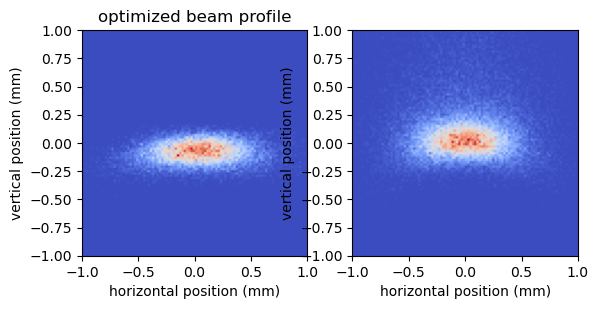

In [177]:
# beam flux density (max), beam size and slit size (min)
X, Y, I = beamline_531(0.000229, 2644.42334, 0.001495, 0.000164, 0.003985, 0.000618)
print(beam_rms_size(X, Y, I))
plt.subplot(1,2,1)
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-1, 1]])
plt.imshow(hist3.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal')
plt.title('optimized beam profile')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
X, Y, I = beamline_531(0.0, 2400, 0.0, 0.0, 2, 2)
print(beam_rms_size(X, Y, I))
plt.subplot(1,2,2)
hist3, xedges, yedges = np.histogram2d(X[I>0]*1e3, Y[I>0]*1e3, bins=100, range=[[-1, 1], [-1, 1]])
plt.imshow(hist3.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')